In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [28]:
dem = pd.read_csv("cleaned DEM data/dem_cleaned.csv")
dpw = pd.read_csv("cleaned quant data/dpw_cleaned.csv")
mjf = pd.read_csv("cleaned quant data/mjf_cleaned.csv")
pema = pd.read_csv("cleaned quant data/pema_cleaned.csv")
pha = pd.read_csv("cleaned quant data/pha_cleaned.csv")

In [29]:
for df in [dem, dpw, mjf, pema, pha]:
    df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])

#create no2 dataframe
no2_df = (
    dem[["datetime_utc", "no2"]].rename(columns={"no2": "dem"})
    .merge(
        dpw[["datetime_utc", "no2"]].rename(columns={"no2": "dpw"}),
        on="datetime_utc",
        how="inner"
    )
    .merge(
        mjf[["datetime_utc", "no2"]].rename(columns={"no2": "mjf"}),
        on="datetime_utc",
        how="inner"
    )
    .merge(
        pema[["datetime_utc", "no2"]].rename(columns={"no2": "pema"}),
        on="datetime_utc",
        how="inner"
    )
    .merge(
        pha[["datetime_utc", "no2"]].rename(columns={"no2": "pha"}),
        on="datetime_utc",
        how="inner"
    )
    .sort_values("datetime_utc")
    .reset_index(drop=True)
)

In [30]:
#create o3 dataframe

o3_df = (
    dem[["datetime_utc", "o3"]].rename(columns={"o3": "dem"})
    .merge(
        dpw[["datetime_utc", "o3"]].rename(columns={"o3": "dpw"}),
        on="datetime_utc",
        how="inner"
    )
    .merge(
        mjf[["datetime_utc", "o3"]].rename(columns={"o3": "mjf"}),
        on="datetime_utc",
        how="inner"
    )
    .merge(
        pema[["datetime_utc", "o3"]].rename(columns={"o3": "pema"}),
        on="datetime_utc",
        how="inner"
    )
    .merge(
        pha[["datetime_utc", "o3"]].rename(columns={"o3": "pha"}),
        on="datetime_utc",
        how="inner"
    )
    .sort_values("datetime_utc")
    .reset_index(drop=True)
)

In [31]:
#drop negative values indiviudally, not rows
site_cols_no2 = [c for c in no2_df.columns if c != "datetime_utc"]
no2_df[site_cols_no2] = no2_df[site_cols_no2].mask(no2_df[site_cols_no2] < 0)

site_cols_o3 = [c for c in o3_df.columns if c != "datetime_utc"]
o3_df[site_cols_o3] = o3_df[site_cols_o3].mask(o3_df[site_cols_o3] < 0)

In [32]:
no2_df.to_csv("low RSD ready data/no2_bysite.csv", index=False)
o3_df.to_csv("low RSD ready data/o3_bysite.csv", index=False)

## Slight EDA to get better sense of available data

In [33]:
#date range of available data
print("NO2")
print("Start:", no2_df["datetime_utc"].min())
print("End:", no2_df["datetime_utc"].max())
print("")

print("O3")
print("Start:", o3_df["datetime_utc"].min())
print("End:", o3_df["datetime_utc"].max())

NO2
Start: 2025-10-09 22:00:00
End: 2026-05-31 23:00:00

O3
Start: 2025-10-09 22:00:00
End: 2026-05-31 23:00:00


In [34]:
#number of observations
total_no2 = len(no2_df)
total_o3 = len(o3_df)

print("NO2 total observations:", total_no2)
print("O3 total observations:", total_o3)

NO2 total observations: 5618
O3 total observations: 5618


In [35]:
missing_no2 = no2_df.drop(columns="datetime_utc").isna().any(axis=1).sum()
missing_o3 = o3_df.drop(columns="datetime_utc").isna().any(axis=1).sum()

print("NO2 rows with at least one missing value:", missing_no2)
print("O3 rows with at least one missing value:", missing_o3)

NO2 rows with at least one missing value: 840
O3 rows with at least one missing value: 911


In [36]:
print("NO2 missing values by site:")
print(no2_df.isna().sum())
print("")

print("O3 missing values by site:")
print(o3_df.isna().sum())

NO2 missing values by site:
datetime_utc      0
dem             434
dpw               5
mjf               2
pema            416
pha               2
dtype: int64

O3 missing values by site:
datetime_utc      0
dem             268
dpw              50
mjf               6
pema            566
pha             212
dtype: int64


<Figure size 640x480 with 0 Axes>

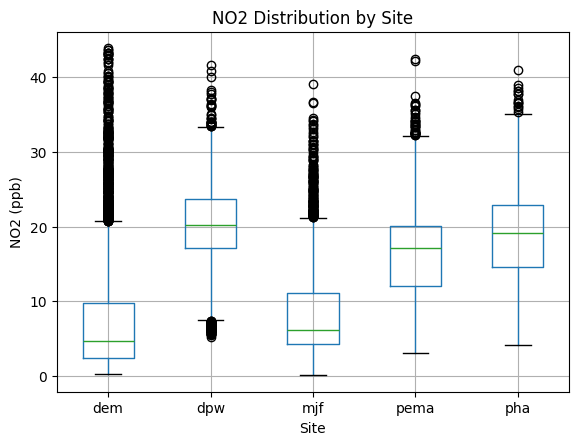

In [37]:
no2_melted = no2_df.melt(id_vars="datetime_utc", var_name="site", value_name="no2")

plt.figure()
no2_melted.boxplot(column="no2", by="site")
plt.title("NO2 Distribution by Site")
plt.suptitle("")
plt.xlabel("Site")
plt.ylabel("NO2 (ppb)")
plt.show()

<Figure size 640x480 with 0 Axes>

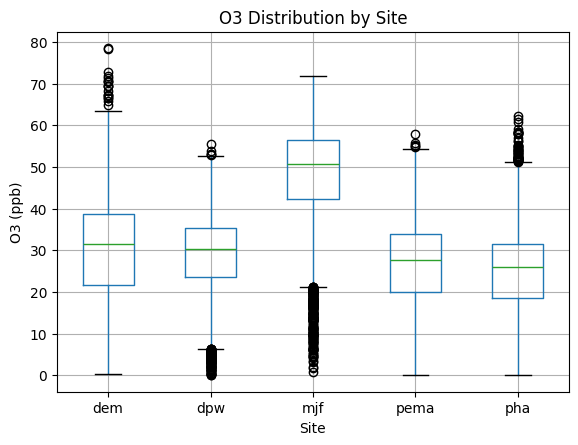

In [38]:
o3_melted = o3_df.melt(id_vars="datetime_utc", var_name="site", value_name="o3")

plt.figure()
o3_melted.boxplot(column="o3", by="site")
plt.title("O3 Distribution by Site")
plt.suptitle("")
plt.xlabel("Site")
plt.ylabel("O3 (ppb)")
plt.show()

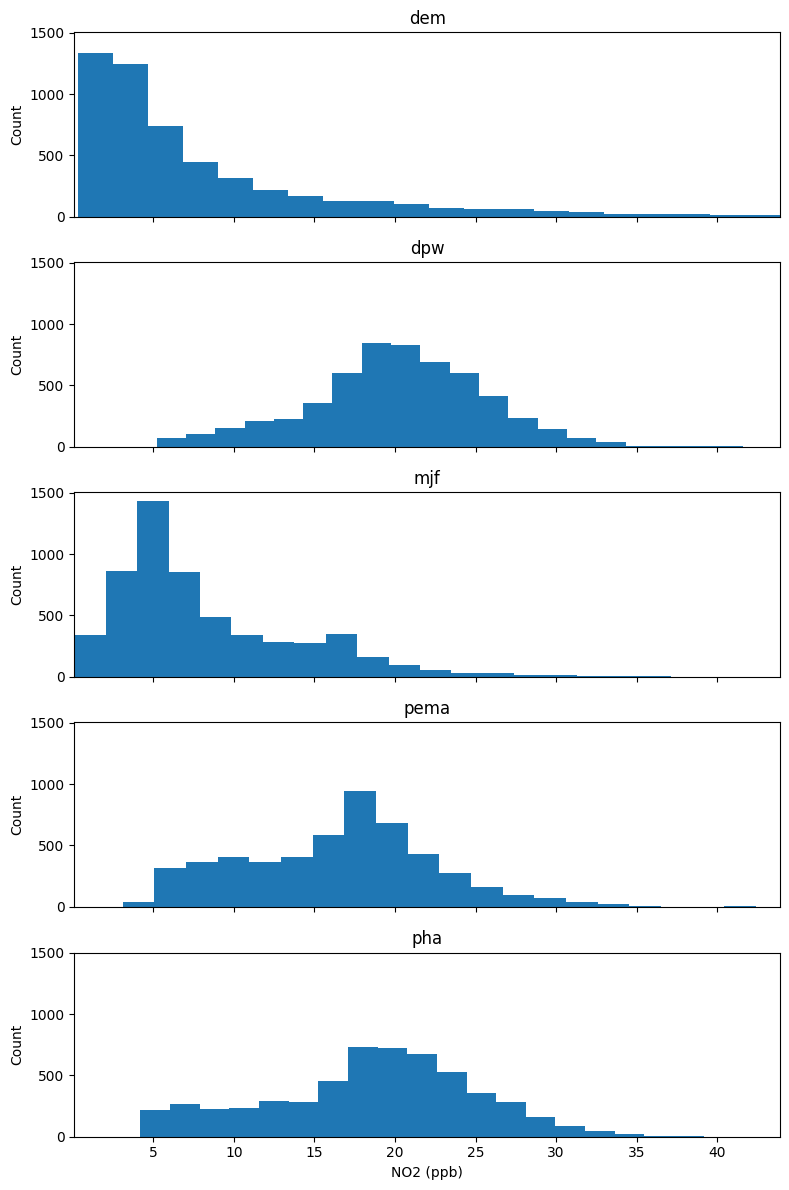

In [39]:
sites = ["dem", "dpw", "mjf", "pema", "pha"]

#define x axis limits for al sites
xmin = no2_df[sites].min().min()
xmax = no2_df[sites].max().max()

fig, axes = plt.subplots(
    nrows=len(sites),
    ncols=1,
    figsize=(8, 12),
    sharex=True,
    sharey=True
)

for ax, site in zip(axes, sites):
    ax.hist(no2_df[site].dropna(), bins=20)
    ax.set_title(site)
    ax.set_ylabel("Count")

for ax in axes:
    ax.set_xlim(xmin, xmax)

axes[-1].set_xlabel("NO2 (ppb)")

plt.tight_layout()
plt.show()

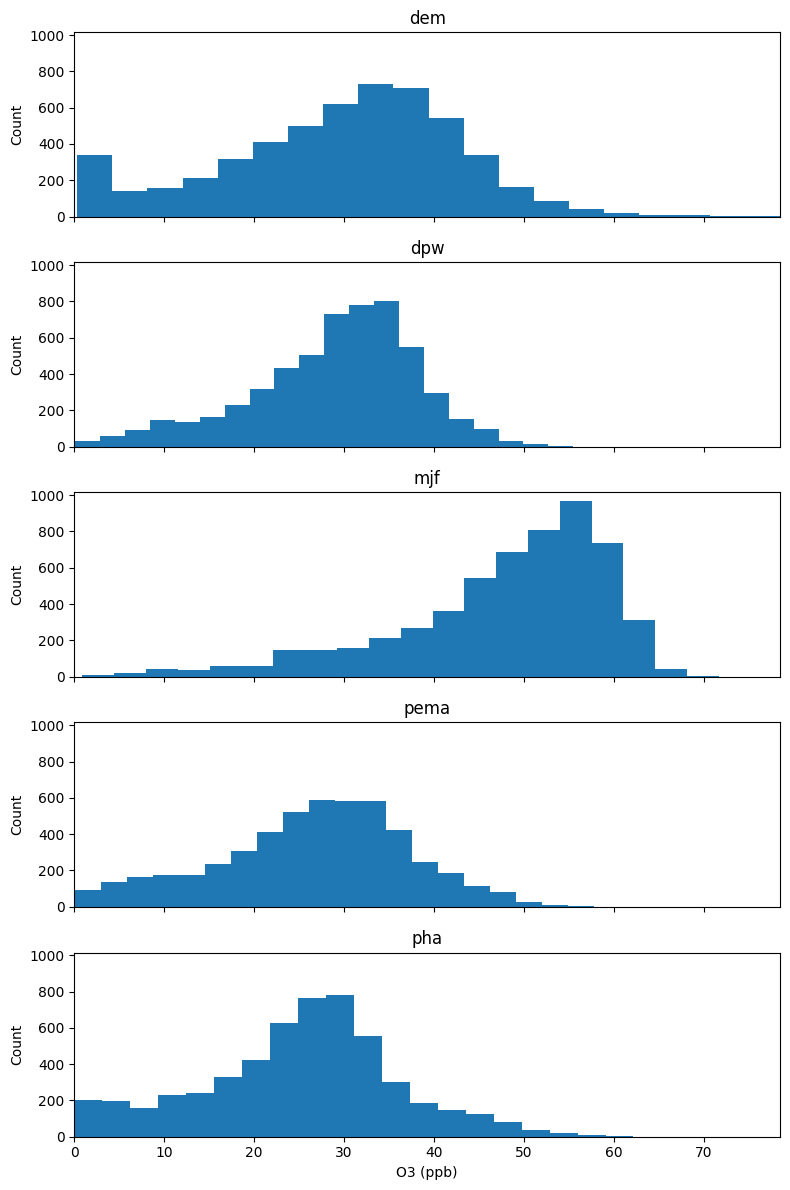

In [40]:
sites = ["dem", "dpw", "mjf", "pema", "pha"]

#define x axis limits for al sites
xmin = o3_df[sites].min().min()
xmax = o3_df[sites].max().max()

fig, axes = plt.subplots(
    nrows=len(sites),
    ncols=1,
    figsize=(8, 12),
    sharex=True,
    sharey=True
)

for ax, site in zip(axes, sites):
    ax.hist(o3_df[site].dropna(), bins=20)
    ax.set_title(site)
    ax.set_ylabel("Count")

for ax in axes:
    ax.set_xlim(xmin, xmax)

axes[-1].set_xlabel("O3 (ppb)")

plt.tight_layout()
plt.show()